# 06 — Audio features classification

In the previous notebook, we converted each audio file into a row of numerical features.

Now we use those features to train a simple classifier.

## Learning goals

By the end of this notebook, students should be able to explain this pipeline:

```text
feature table
    ↓
train/test split
    ↓
feature scaling
    ↓
classifier
    ↓
predictions
    ↓
evaluation
```

The key idea is:

> Audio classification can be approached as a supervised machine-learning problem once each audio file has been converted into a feature vector.

## Imports

In [26]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

## Project paths

In [27]:
PROJECT_ROOT = Path.cwd()

while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "README.md").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

FEATURES_CSV = PROJECT_ROOT / "outputs" / "features" / "esc50_audio_features.csv"

print("Project root:", PROJECT_ROOT)
print("Feature table:", FEATURES_CSV)

Project root: /Users/vpoblete/Documents/20230208_vpoblete/20260620_info343_classes/audio-data-mining-class
Feature table: /Users/vpoblete/Documents/20230208_vpoblete/20260620_info343_classes/audio-data-mining-class/outputs/features/esc50_audio_features.csv


## Plot style utilities

In [28]:
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from plot_config import (
    apply_plot_style,
    clean_axes,
    GRAYSCALE,
    ACCENT,
    FIGSIZE_WIDE,
    FIGSIZE_TALL,
    DPI,
)

apply_plot_style()

## Load the feature table

If this cell fails because the CSV does not exist, run notebook `05_feature_extraction.ipynb` first.

In [29]:
features_df = pd.read_csv(FEATURES_CSV)

print("Feature table shape:", features_df.shape)
features_df.head()

Feature table shape: (80, 51)


,filename,category,target,duration_s,sampling_rate,rms_mean,rms_std,rms_min,rms_max,zcr_mean,...,mfcc_08_mean,mfcc_08_std,mfcc_09_mean,mfcc_09_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std
0,1-100038-A-14.wav,chirping_birds,14,5.0,44100,0.048115,0.038114,0.016259,0.241998,0.157994,...,-11.705071,7.955853,-17.621454,8.934216,-26.893171,10.558152,-13.461914,7.269026,-9.417187,6.993200
1,1-34495-A-14.wav,chirping_birds,14,5.0,44100,0.054410,0.065113,0.014088,0.272005,0.172669,...,-7.826603,8.451578,24.947496,10.026748,-9.441930,7.953942,3.315334,8.974554,-14.367867,6.796442
2,1-34497-A-14.wav,chirping_birds,14,5.0,44100,0.024467,0.007098,0.012339,0.064768,0.214568,...,-20.033266,8.808902,20.341619,7.410479,-19.248188,7.617902,12.599248,7.122535,-23.226843,6.536869
3,1-38559-A-14.wav,chirping_birds,14,5.0,44100,0.009480,0.006181,0.001023,0.023706,0.143265,...,-24.379923,6.393528,5.893976,9.036790,-22.354820,6.079295,-6.182848,9.611876,-15.564694,9.505658
4,1-38560-A-14.wav,chirping_birds,14,5.0,44100,0.005041,0.005941,0.000606,0.025639,0.214983,...,-22.433643,11.821642,-0.792322,7.988717,-19.612755,8.865774,3.564663,6.072551,-17.621767,7.828809


## Prepare features and labels

We separate:

```text
X → numerical features
y → class labels
```

We remove metadata columns such as filename and category from the input features.

In [30]:
label_column = "category"

metadata_columns = [
    "filename",
    "category",
    "target",
]

feature_columns = [
    col for col in features_df.columns
    if col not in metadata_columns
]

X = features_df[feature_columns]
y = features_df[label_column]

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Number of classes:", y.nunique())

y.value_counts()

Number of samples: 80
Number of features: 48
Number of classes: 8


category
chirping_birds     10
clock_tick         10
dog                10
helicopter         10
keyboard_typing    10
rain               10
sea_waves          10
sneezing           10
Name: count, dtype: int64

### What does `X = features_df[feature_columns]` mean?

The complete table `features_df` contains both metadata and numerical features.

For example:

```text
metadata columns → filename, category, target
feature columns  → rms_mean, zcr_mean, spectral_centroid_mean, mfcc_00_mean, ...
```

The classifier should not use the filename or the class label as input.  
It should only receive numerical descriptors of the audio signal.

Therefore:

```python
X = features_df[feature_columns]
```

means:

> From the complete table, select only the numerical feature columns that will be used as input to the model.

In supervised learning:

```text
X → input matrix: one row per audio file, one column per feature
y → output labels: the class/category we want to predict
```

In [31]:
# x_matrix_explanation_demo
# Inspect how the complete table is converted into X and y.

print("All columns in features_df:")
print(list(features_df.columns))

print("\nMetadata columns removed from X:")
print(metadata_columns)

print("\nColumns used as input features X:")
print(feature_columns)

print("\nShape of features_df:", features_df.shape)
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

print("\nFirst rows of X:")
X.head()

All columns in features_df:
['filename', 'category', 'target', 'duration_s', 'sampling_rate', 'rms_mean', 'rms_std', 'rms_min', 'rms_max', 'zcr_mean', 'zcr_std', 'zcr_min', 'zcr_max', 'spectral_centroid_mean', 'spectral_centroid_std', 'spectral_centroid_min', 'spectral_centroid_max', 'spectral_bandwidth_mean', 'spectral_bandwidth_std', 'spectral_bandwidth_min', 'spectral_bandwidth_max', 'spectral_rolloff_mean', 'spectral_rolloff_std', 'spectral_rolloff_min', 'spectral_rolloff_max', 'mfcc_00_mean', 'mfcc_00_std', 'mfcc_01_mean', 'mfcc_01_std', 'mfcc_02_mean', 'mfcc_02_std', 'mfcc_03_mean', 'mfcc_03_std', 'mfcc_04_mean', 'mfcc_04_std', 'mfcc_05_mean', 'mfcc_05_std', 'mfcc_06_mean', 'mfcc_06_std', 'mfcc_07_mean', 'mfcc_07_std', 'mfcc_08_mean', 'mfcc_08_std', 'mfcc_09_mean', 'mfcc_09_std', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std']

Metadata columns removed from X:
['filename', 'category', 'target']

Columns used as input features X:
['dura

,duration_s,sampling_rate,rms_mean,rms_std,rms_min,rms_max,zcr_mean,zcr_std,zcr_min,zcr_max,...,mfcc_08_mean,mfcc_08_std,mfcc_09_mean,mfcc_09_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std
0,5.0,44100,0.048115,0.038114,0.016259,0.241998,0.157994,0.022784,0.077148,0.218750,...,-11.705071,7.955853,-17.621454,8.934216,-26.893171,10.558152,-13.461914,7.269026,-9.417187,6.993200
1,5.0,44100,0.054410,0.065113,0.014088,0.272005,0.172669,0.051918,0.062988,0.369629,...,-7.826603,8.451578,24.947496,10.026748,-9.441930,7.953942,3.315334,8.974554,-14.367867,6.796442
2,5.0,44100,0.024467,0.007098,0.012339,0.064768,0.214568,0.038416,0.088379,0.304199,...,-20.033266,8.808902,20.341619,7.410479,-19.248188,7.617902,12.599248,7.122535,-23.226843,6.536869
3,5.0,44100,0.009480,0.006181,0.001023,0.023706,0.143265,0.032134,0.068359,0.235352,...,-24.379923,6.393528,5.893976,9.036790,-22.354820,6.079295,-6.182848,9.611876,-15.564694,9.505658
4,5.0,44100,0.005041,0.005941,0.000606,0.025639,0.214983,0.065815,0.064941,0.324707,...,-22.433643,11.821642,-0.792322,7.988717,-19.612755,8.865774,3.564663,6.072551,-17.621767,7.828809


### One audio file as one feature vector

Each row of `X` represents one audio file.

That row contains all the selected numerical features at once:

```text
one audio file → one feature vector
```

This vector can include RMS features, zero-crossing features, spectral features, and MFCC summary features.

In [32]:
# one_audio_as_feature_vector_demo
# Show one audio file represented as one feature vector.

example_row = 0

print("Audio file:", features_df.loc[example_row, "filename"])
print("Class label:", y.iloc[example_row])
print("Number of features in this vector:", X.shape[1])

X.iloc[[example_row]]

Audio file: 1-100038-A-14.wav
Class label: chirping_birds
Number of features in this vector: 48


,duration_s,sampling_rate,rms_mean,rms_std,rms_min,rms_max,zcr_mean,zcr_std,zcr_min,zcr_max,...,mfcc_08_mean,mfcc_08_std,mfcc_09_mean,mfcc_09_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std
0,5.0,44100,0.048115,0.038114,0.016259,0.241998,0.157994,0.022784,0.077148,0.21875,...,-11.705071,7.955853,-17.621454,8.934216,-26.893171,10.558152,-13.461914,7.269026,-9.417187,6.9932


### How many features are used per audio file?

Each audio file is represented by one row in `X`.

The number of features per audio file is the number of columns in `X`:

```python
X.shape[1]
```

In this notebook, the feature vector includes different groups of descriptors:

```text
duration and sampling information
time-domain features
spectral features
MFCC summary features
```

Conceptually:

```text
one audio file → one vector of numerical features
```

So, if `X.shape` is:

```text
(number_of_audio_files, number_of_features)
```

then `number_of_features` tells us how many numerical descriptors are used to represent each audio file.

In [33]:
# feature_count_explanation_demo
# Count how many input features are used per audio file.

number_of_audio_files = X.shape[0]
number_of_features = X.shape[1]

print("Shape of X:", X.shape)
print("Number of audio files:", number_of_audio_files)
print("Number of features per audio file:", number_of_features)

Shape of X: (80, 48)
Number of audio files: 80
Number of features per audio file: 48


In [34]:
# feature_group_summary_demo
# Group the feature columns to understand what types of descriptors are included.

feature_groups = {
    "duration_and_sampling": [
        col for col in feature_columns
        if col in ["duration_s", "sampling_rate"]
    ],
    "rms": [
        col for col in feature_columns
        if col.startswith("rms_")
    ],
    "zero_crossing_rate": [
        col for col in feature_columns
        if col.startswith("zcr_")
    ],
    "spectral_centroid": [
        col for col in feature_columns
        if col.startswith("spectral_centroid_")
    ],
    "spectral_bandwidth": [
        col for col in feature_columns
        if col.startswith("spectral_bandwidth_")
    ],
    "spectral_rolloff": [
        col for col in feature_columns
        if col.startswith("spectral_rolloff_")
    ],
    "mfcc": [
        col for col in feature_columns
        if col.startswith("mfcc_")
    ],
}

feature_group_summary = (
    pd.DataFrame(
        [
            {
                "feature_group": group_name,
                "n_features": len(columns),
                "columns": ", ".join(columns),
            }
            for group_name, columns in feature_groups.items()
        ]
    )
)

feature_group_summary.loc[
    len(feature_group_summary)
] = {
    "feature_group": "total",
    "n_features": len(feature_columns),
    "columns": "",
}

feature_group_summary

,feature_group,n_features,columns
0,duration_and_sampling,2,"duration_s, sampling_rate"
1,rms,4,"rms_mean, rms_std, rms_min, rms_max"
2,zero_crossing_rate,4,"zcr_mean, zcr_std, zcr_min, zcr_max"
3,spectral_centroid,4,"spectral_centroid_mean, spectral_centroid_std,..."
4,spectral_bandwidth,4,"spectral_bandwidth_mean, spectral_bandwidth_st..."
5,spectral_rolloff,4,"spectral_rolloff_mean, spectral_rolloff_std, s..."
6,mfcc,26,"mfcc_00_mean, mfcc_00_std, mfcc_01_mean, mfcc_..."
7,total,48,


For the current feature table, this should give:

```text
48 features per audio file
```

That means each audio file is converted into a vector of 48 numbers before classification.

A useful teaching sentence is:

> The classifier does not receive the waveform directly. It receives a table where each audio file is represented by a vector of numerical features.

In summary:

duration_s              → 1

sampling_rate           → 1

Time-domain features:

rms                     → mean, std, min, max = 4

zcr                     → mean, std, min, max = 4

Spectral features:

spectral_centroid       → mean, std, min, max = 4

spectral_bandwidth      → mean, std, min, max = 4

spectral_rolloff        → mean, std, min, max = 4

MFCCs:

13 MFCCs × 2 estadísticas → mean y std = 26

Then,

2 + 4 + 4 + 4 + 4 + 4 + 26 = 48 features

## Train/test split

We reserve part of the data for testing.

The classifier will not see the test set during training.

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 56
Test samples: 24


## Baseline classifier: logistic regression

We use a pipeline with two steps:

```text
StandardScaler → LogisticRegression
```

Scaling is important because features may have very different numerical ranges.

In [36]:
logreg_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42,
    )),
])

logreg_model.fit(X_train, y_train)

y_pred_logreg = logreg_model.predict(X_test)

accuracy_logreg = accuracy_score(y_test, y_pred_logreg)

print("Logistic regression accuracy:", accuracy_logreg)

Logistic regression accuracy: 0.875


## Classification report

The classification report gives precision, recall, and F1-score per class.

For small datasets, interpret these numbers carefully. They are useful for learning, but not final scientific evidence.

In [37]:
print(classification_report(y_test, y_pred_logreg))

                 precision    recall  f1-score   support

 chirping_birds       0.75      1.00      0.86         3
     clock_tick       1.00      0.67      0.80         3
            dog       1.00      0.67      0.80         3
     helicopter       1.00      1.00      1.00         3
keyboard_typing       1.00      1.00      1.00         3
           rain       0.75      1.00      0.86         3
      sea_waves       1.00      0.67      0.80         3
       sneezing       0.75      1.00      0.86         3

       accuracy                           0.88        24
      macro avg       0.91      0.88      0.87        24
   weighted avg       0.91      0.88      0.87        24



### What does support mean?

In the classification report, **support** is the number of real test examples for each class.

For example, if the report says:

```text
support = 3
```

for one class, it means:

> There were 3 real audio files of that class in the test set.

It does **not** mean that the model correctly classified 3 examples.  
It only tells us how many examples of that class were available for evaluation.

In this notebook, each class has 10 audio files in the subset, and we used:

```python
test_size = 0.30
```

Therefore:

```text
10 audio files per class × 30% for testing = 3 test examples per class
```

This is why the support is usually 3 for each class.

Because the test set is small, the metrics should be interpreted carefully: one correct or incorrect prediction can change the percentages a lot.

In [38]:
# support_explanation_demo
# Count how many real test examples belong to each class.

support_table = (
    y_test
    .value_counts()
    .sort_index()
    .rename_axis("class")
    .reset_index(name="support")
)

support_table

,class,support
0,chirping_birds,3
1,clock_tick,3
2,dog,3
3,helicopter,3
4,keyboard_typing,3
5,rain,3
6,sea_waves,3
7,sneezing,3


## Confusion matrix

The confusion matrix shows which classes are correctly classified and which classes are confused.

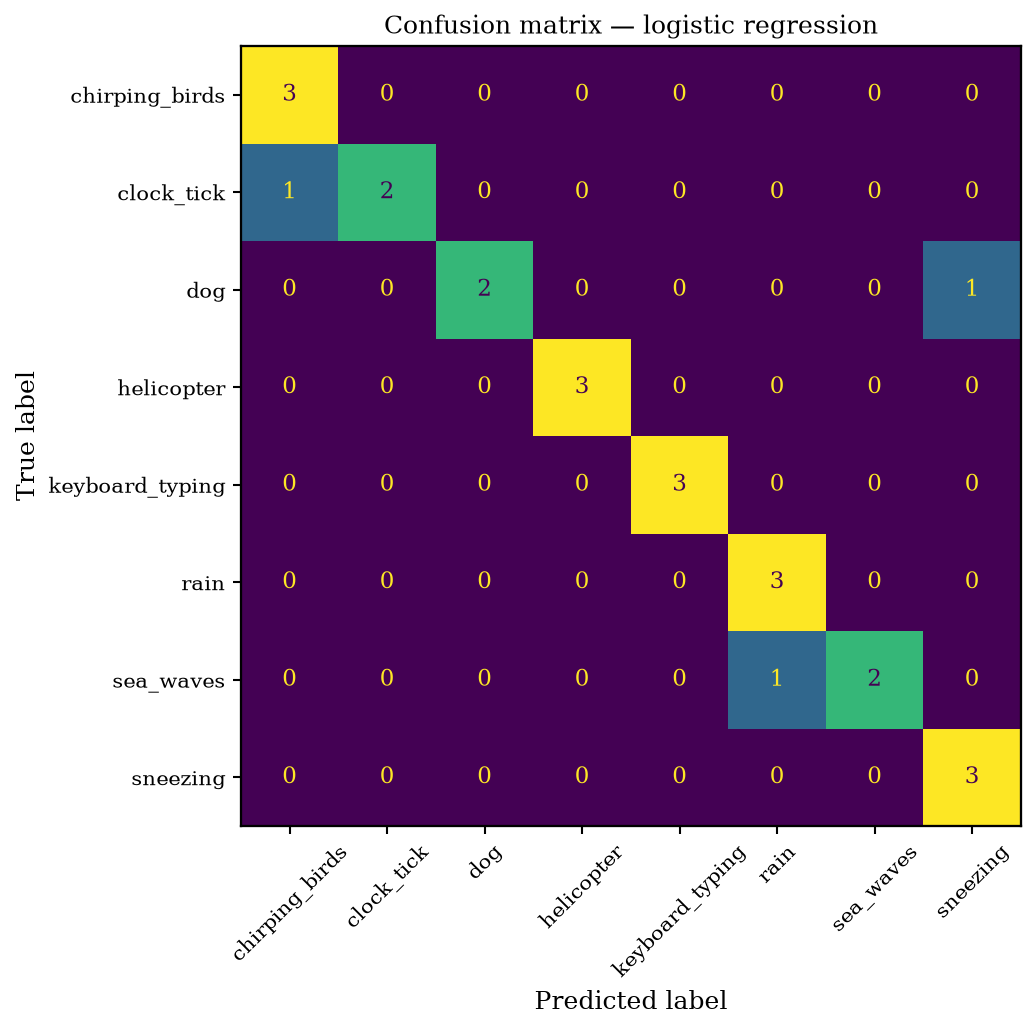

In [39]:
fig, ax = plt.subplots(figsize=(8, 7), dpi=DPI)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logreg,
    ax=ax,
    xticks_rotation=45,
    colorbar=False,
)

ax.set_title("Confusion matrix — logistic regression")

plt.tight_layout()
plt.show()

## A second model: Random Forest

Random Forests can capture nonlinear relationships and do not require feature scaling.

We use it as a comparison, not necessarily because it is always better.

In [40]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest accuracy:", accuracy_rf)

Random Forest accuracy: 0.7083333333333334


In [41]:
print(classification_report(y_test, y_pred_rf))

                 precision    recall  f1-score   support

 chirping_birds       0.67      0.67      0.67         3
     clock_tick       0.50      0.67      0.57         3
            dog       1.00      0.67      0.80         3
     helicopter       1.00      1.00      1.00         3
keyboard_typing       0.33      0.33      0.33         3
           rain       0.75      1.00      0.86         3
      sea_waves       1.00      0.33      0.50         3
       sneezing       0.75      1.00      0.86         3

       accuracy                           0.71        24
      macro avg       0.75      0.71      0.70        24
   weighted avg       0.75      0.71      0.70        24



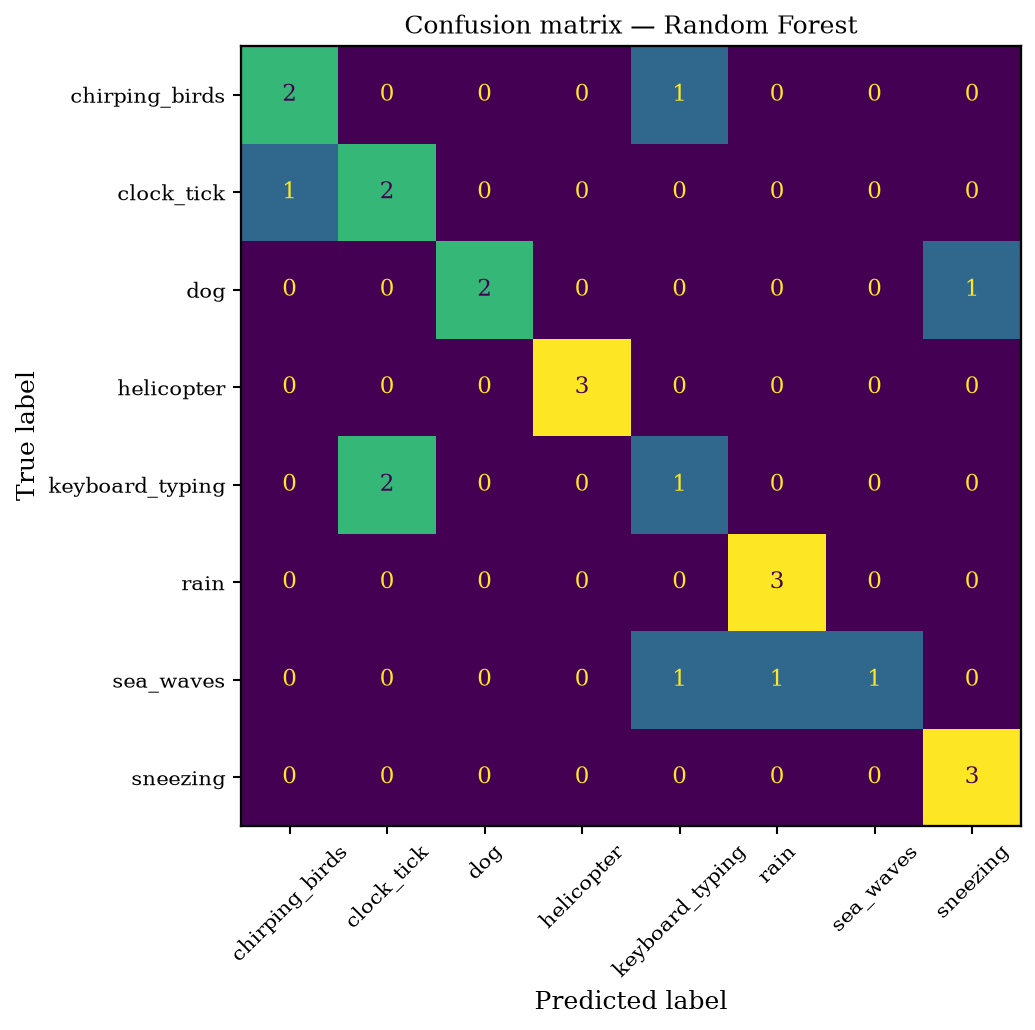

In [42]:
fig, ax = plt.subplots(figsize=(8, 7), dpi=DPI)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    ax=ax,
    xticks_rotation=45,
    colorbar=False,
)

ax.set_title("Confusion matrix — Random Forest")

plt.tight_layout()
plt.show()

## Compare model accuracy

In [43]:
model_comparison = pd.DataFrame({
    "model": ["Logistic regression", "Random Forest"],
    "test_accuracy": [accuracy_logreg, accuracy_rf],
})

model_comparison

,model,test_accuracy
0,Logistic regression,0.875000
1,Random Forest,0.708333


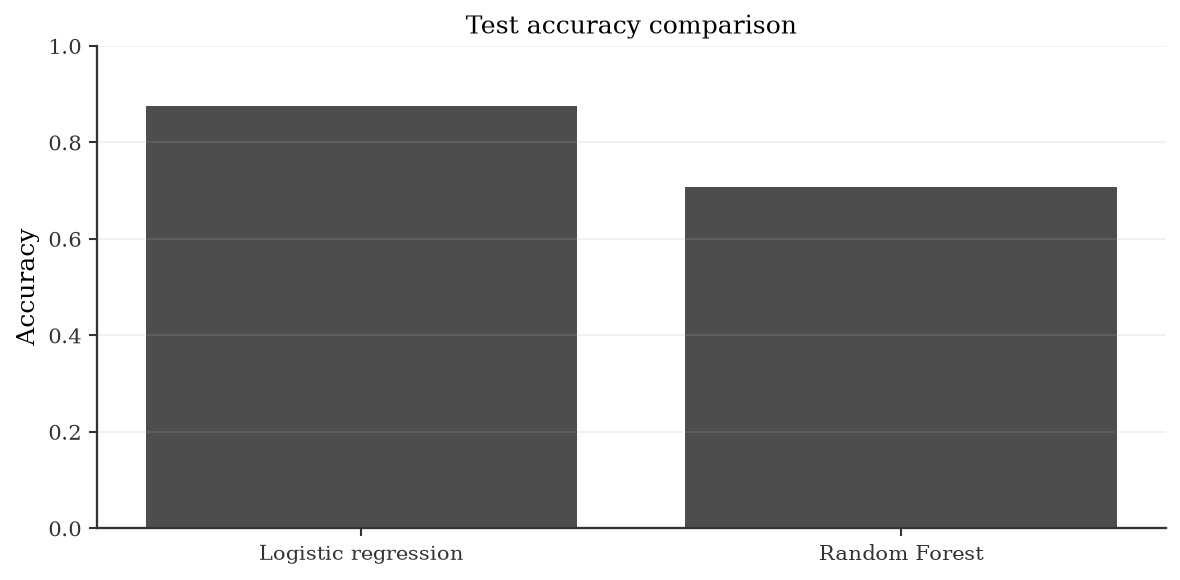

In [44]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=DPI)

ax.bar(
    model_comparison["model"],
    model_comparison["test_accuracy"],
    color=GRAYSCALE["secondary"],
)

ax.set_title("Test accuracy comparison")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)

clean_axes(ax, grid_axis="y")

plt.tight_layout()
plt.show()

## Cross-validation

A single train/test split can be unstable, especially with a small dataset.

Cross-validation gives a more robust estimate by repeating the training and testing process across multiple splits.

In [45]:
cv_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42,
    )),
])

cv_scores = cross_val_score(
    cv_model,
    X,
    y,
    cv=5,
    scoring="accuracy",
)

print("Cross-validation scores:", cv_scores)
print("Mean accuracy:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

Cross-validation scores: [0.5625 0.8125 0.8125 0.6875 0.6875]
Mean accuracy: 0.7125
Standard deviation: 0.09354143466934853


## Feature importance from Random Forest

Random Forests provide a simple feature-importance score.

This is not a full explanation of the model, but it can help identify which features were useful.

In [46]:
feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False)

feature_importance.head(15)

,feature,importance
23,mfcc_00_std,0.053505
4,rms_min,0.043910
25,mfcc_01_std,0.042028
22,mfcc_00_mean,0.039745
2,rms_mean,0.038551
26,mfcc_02_mean,0.038005
5,rms_max,0.035571
28,mfcc_03_mean,0.033056
27,mfcc_02_std,0.030824
15,spectral_bandwidth_std,0.030378


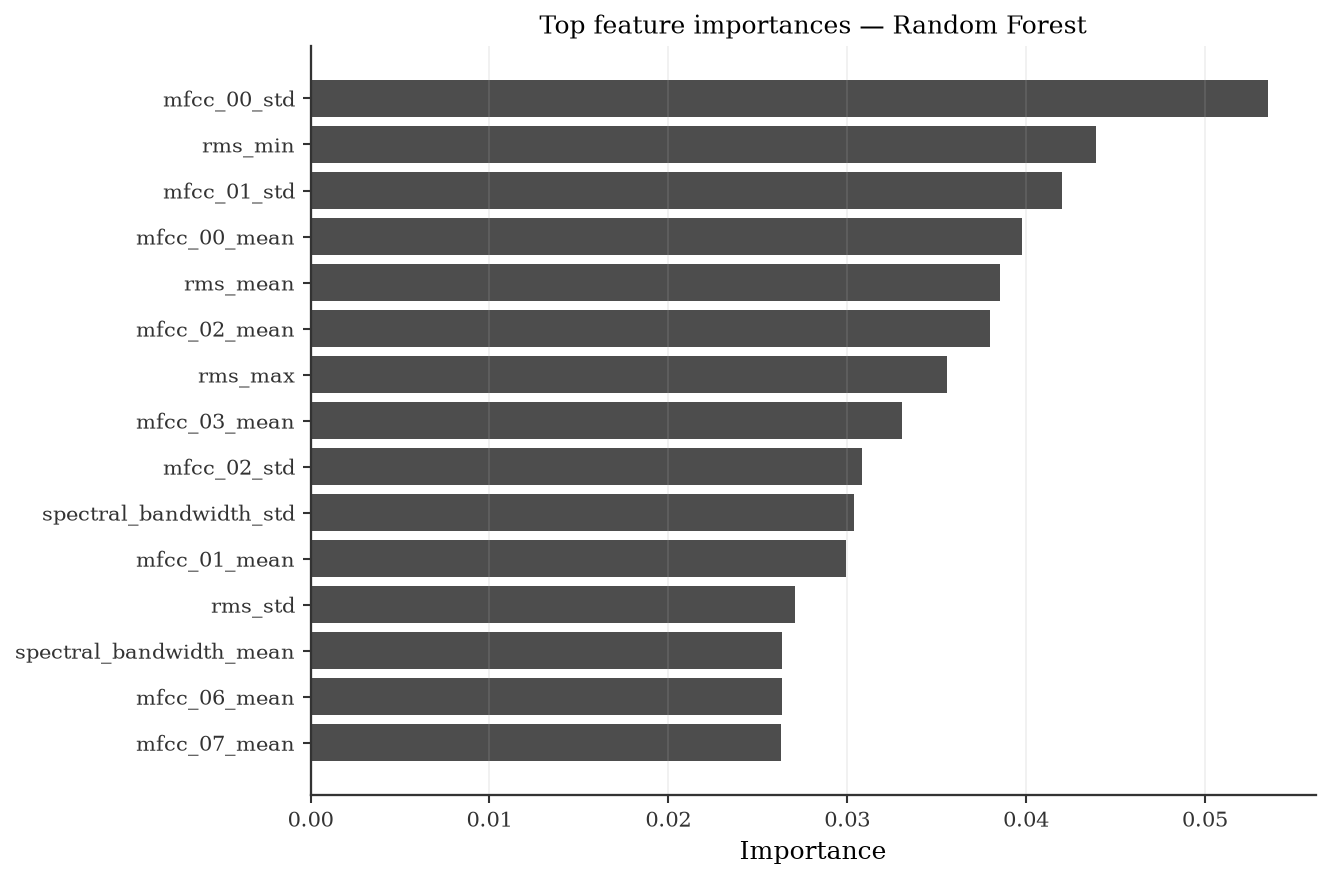

In [47]:
top_n = 15
top_features = feature_importance.head(top_n).iloc[::-1]

fig, ax = plt.subplots(figsize=(9, 6), dpi=DPI)

ax.barh(
    top_features["feature"],
    top_features["importance"],
    color=GRAYSCALE["secondary"],
)

ax.set_title("Top feature importances — Random Forest")
ax.set_xlabel("Importance")

clean_axes(ax, grid_axis="x")

plt.tight_layout()
plt.show()

## Try predicting one selected test example

Instead of choosing an example only by a numerical index, we first build a small table of test examples.

This makes it easier to select a case intentionally:

```text
test_index → position in the test set
filename   → audio file name
true_label → correct class
```

Then we choose one `test_index` from the table and compare the model predictions.

In [48]:
# Build a readable table of test examples.

test_examples = features_df.loc[X_test.index, ["filename", "category"]].copy()
test_examples = test_examples.rename(columns={"category": "true_label"})
test_examples = test_examples.reset_index(drop=True)
test_examples.insert(0, "test_index", test_examples.index)

print("Number of test examples:", len(test_examples))

test_examples

Number of test examples: 24


,test_index,filename,true_label
0,0,1-172649-F-40.wav,helicopter
1,1,1-38559-A-14.wav,chirping_birds
2,2,2-127108-A-38.wav,clock_tick
3,3,1-28135-B-11.wav,sea_waves
4,4,2-102852-A-11.wav,sea_waves
5,5,1-62594-A-32.wav,keyboard_typing
6,6,1-35687-A-38.wav,clock_tick
7,7,1-32318-A-0.wav,dog
8,8,1-97392-A-0.wav,dog
9,9,1-172649-E-40.wav,helicopter


### Select one example

Choose a value from the `test_index` column above.

For example:

```python
selected_test_index = 0
```

You can change this number to inspect a different test example.

In [49]:
# Select one test example by its visible test_index.

selected_test_index = 23

if selected_test_index < 0 or selected_test_index >= len(test_examples):
    raise ValueError(
        f"selected_test_index must be between 0 and {len(test_examples) - 1}."
    )

x_example = X_test.iloc[[selected_test_index]]
true_label = y_test.iloc[selected_test_index]

example_info = test_examples.iloc[selected_test_index]

predicted_logreg = logreg_model.predict(x_example)[0]
predicted_rf = rf_model.predict(x_example)[0]

print("Selected test index:", selected_test_index)
print("Filename:", example_info["filename"])
print("True label:", true_label)
print("Logistic regression prediction:", predicted_logreg)
print("Random Forest prediction:", predicted_rf)

print()
print("Logistic regression correct?", predicted_logreg == true_label)
print("Random Forest correct?", predicted_rf == true_label)

Selected test index: 23
Filename: 1-81883-A-21.wav
True label: sneezing
Logistic regression prediction: sneezing
Random Forest prediction: sneezing

Logistic regression correct? True
Random Forest correct? True


In [50]:
# Same information as a compact table.

single_prediction_summary = pd.DataFrame([
    {
        "model": "Logistic regression",
        "filename": example_info["filename"],
        "true_label": true_label,
        "predicted_label": predicted_logreg,
        "correct": predicted_logreg == true_label,
    },
    {
        "model": "Random Forest",
        "filename": example_info["filename"],
        "true_label": true_label,
        "predicted_label": predicted_rf,
        "correct": predicted_rf == true_label,
    },
])

single_prediction_summary

,model,filename,true_label,predicted_label,correct
0,Logistic regression,1-81883-A-21.wav,sneezing,sneezing,True
1,Random Forest,1-81883-A-21.wav,sneezing,sneezing,True


## What did we learn?

We built a complete audio-classification pipeline:

```text
audio recordings
    ↓
feature extraction
    ↓
feature table
    ↓
supervised classifier
    ↓
predictions and evaluation
```

This is a classical machine-learning approach to audio data mining.

It is not the only approach. Deep learning models may learn representations directly from spectrograms or waveforms.  
However, feature-based pipelines are still very useful because they are interpretable, lightweight, and pedagogically clear.

## Discussion questions

1. Why do we need a train/test split?
2. Why can accuracy be misleading for small datasets?
3. Which classes were confused by the model?
4. Which features appeared most important?
5. What might improve classification performance?
6. What is the difference between handcrafted features and learned features?